In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset

In [2]:
OUTPUT_DIR = r"C:\Courses\Innopolis\2026\ВЭД\Данные2"

# Регрессия

In [3]:
df_po = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_orders_clean.csv")

df_suppliers = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_suppliers.csv")
    .loc[:, ["supplier_id", "country_id", "years_of_relationship", "maturity_score"]]
)

df_countries = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_countries.csv")
    .loc[:, ["country_id", "country_risk_base", "sanctions_risk", "port_efficiency_base", "avg_customs_days"]]
)

df_products = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_products.csv")
    .loc[:, ["product_id", "category_id"]]
)

df_transport_modes = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_transport_modes.csv")
    .loc[:, ["transport_mode_id", "avg_transit_days", "delay_probability"]]
)

df = (
    df_po
    .merge(df_suppliers, how = "left", on = "supplier_id")
    .merge(df_countries, how = "left", on = "country_id")
    .merge(df_products, how = "left", on = "product_id")
    .merge(df_transport_modes, how = "left", on = "transport_mode_id")
)

In [4]:
cat_cols = [
    "transport_mode_id",
    "category_id", 
    "country_id", 
    "payment_method"
]

num_cols = [
    "avg_customs_days",
    "avg_transit_days",
    "port_efficiency_base",
    "country_risk_base",
    "port_congestion_at_order", 
    "shock_index_at_order",
    "years_of_relationship",
    "supplier_reliability",
    "delay_probability"
]
target_col = ["actual_delivery_days"]

In [5]:
data = df.copy()
data = data.sort_values(by = "po_id")
data = data.set_index("po_id")
data = data[(data["is_fraud"] == False)&(data["actual_delivery_days"].notna())]
data = data[num_cols + cat_cols + target_col].dropna()

In [6]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
X_train = train_data[num_cols + cat_cols]
X_test = test_data[num_cols + cat_cols]
y_train = train_data[target_col]
y_test = test_data[target_col]

In [7]:
def evaluate_model(y_pred, y_test):
    print("MAE:", round(mean_absolute_error(y_test, y_pred),4))
    print("MAPE:", round(mean_absolute_percentage_error(y_test, y_pred), 4))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
    print("R2:", round(r2_score(y_test, y_pred), 4))

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

batch_size = 256

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [11]:
input_dim = X_train_tensor.shape[1]

class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

model = RegressionNN(input_dim)

In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

n_epochs = 50

for epoch in range(n_epochs):

    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        preds = model(X_batch)

        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(X_batch)

    epoch_loss /= len(train_dataset)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{n_epochs}, "
            f"Loss: {epoch_loss:.6f}"
        )

Epoch 10/50, Loss: 19.325180
Epoch 20/50, Loss: 8.291894
Epoch 30/50, Loss: 7.364392
Epoch 40/50, Loss: 7.146402
Epoch 50/50, Loss: 6.988989


In [15]:
model.eval()

with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_test = model(X_test_tensor)

y_pred_train = y_pred_train.cpu().numpy().ravel()
y_pred_test = y_pred_test.cpu().numpy().ravel()

print("Evaluate train sample")
evaluate_model(y_pred_train, y_train.values)

print("Evaluate test sample")
evaluate_model(y_pred_test, y_test.values)

Evaluate train sample
MAE: 2.012
MAPE: 0.1141
RMSE: 2.633
R2: 0.9646
Evaluate test sample
MAE: 2.1275
MAPE: 0.1198
RMSE: 2.732
R2: 0.963


In [41]:
predicted_delivery_days = (
    pd.concat(
                [
                    pd.DataFrame(y_pred_train.reshape(-1,1), index = y_train.index), 
                    pd.DataFrame(y_pred_test.reshape(-1,1), index = y_test.index)
                ]
            )
    .rename(columns = {0 : "predicted_delivery_days"})
    .sort_index()
    .reset_index(drop = False)
)



In [45]:
df_po = df_po.merge(predicted_delivery_days, how = "left", on = "po_id")

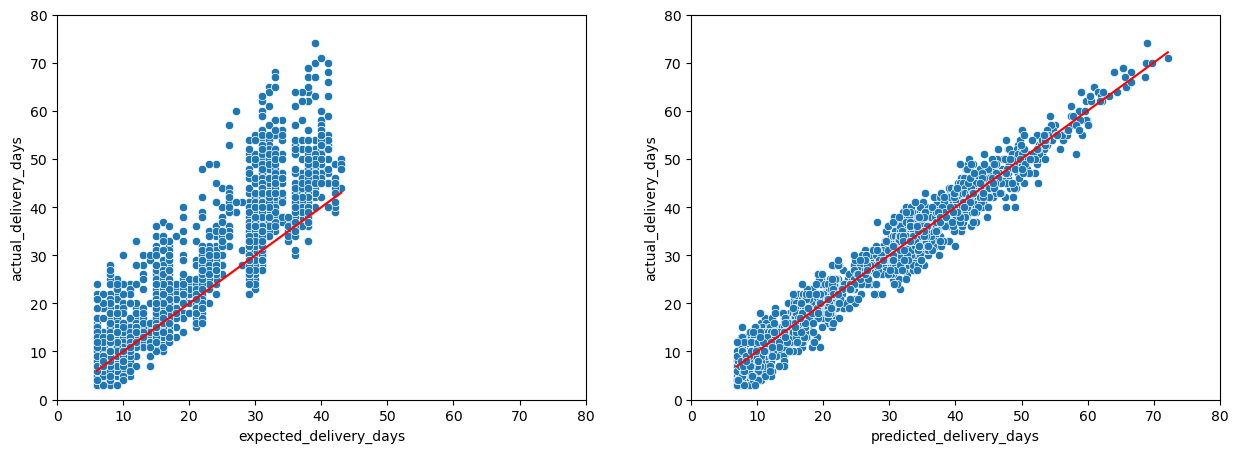

In [46]:
fig, ax = plt.subplots(1,2, figsize = (15,5))
sns.scatterplot(x = "expected_delivery_days", y = "actual_delivery_days", data = df_po, ax = ax[0])
sns.lineplot(x = "expected_delivery_days", y = "expected_delivery_days",data = df_po, ax = ax[0], color = 'red')
sns.scatterplot(x = "predicted_delivery_days", y = "actual_delivery_days", data = df_po, ax = ax[1])
sns.lineplot(x = "predicted_delivery_days", y = "predicted_delivery_days",data = df_po, ax = ax[1], color = 'red')
ax[0].set_xlim(0, 80)
ax[0].set_ylim(0, 80)
ax[1].set_xlim(0, 80)
ax[1].set_ylim(0, 80)
plt.show()

# Временные ряды

In [9]:
df_port_congestion = pd.read_csv(f"{OUTPUT_DIR}\\fact_port_congestion.csv")
df_port_congestion["date"] = pd.to_datetime(df_port_congestion["date"])

In [10]:
def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
 
 
def evaluate_model(y_true, y_pred):
    print("MAE : ",   np.round(mean_absolute_error(y_true, y_pred),4))
    print("RMSE : ", np.round(np.sqrt(mean_squared_error(y_true, y_pred)),4))
    print("MAPE : ", np.round(mape(y_true, y_pred),4))
    print("R2 : ", np.round(r2_score(y_true, y_pred),4))

def plot_forecast(train, test, fcst, ci = None):
    fig, ax = plt.subplots(1,1, figsize = (15,5))
    ax.plot(train.index, train, color="#aec7e8", linewidth=1.2, label="Обучающая")
    ax.plot(test.index, test, color="#1f77b4", linewidth=1.8, label="Тестовая")
    ax.plot(fcst.index, fcst, color="#d62728", linewidth=1.6, linestyle="--", label="Прогноз")
    ax.axvline(test.index[0], color="gray", linestyle=":", linewidth=1.2)
    if (ci is None) or (ci.empty):
        pass
    else:
        ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color="#d62728", label=f"{int((1-ALPHA)*100)}% CI")
    ax.set_title(f"Фактические значения против прогнозных")
    plt.show()

In [11]:
TEST_SIZE = 365

df_cnsha = df_port_congestion.loc[df_port_congestion["port_id"] == "CNSHA", ["date", "congestion_index"]]
df_cnsha = df_cnsha.set_index("date")

train = df_cnsha[:'2024']
test  = df_cnsha['2025':]
print(f"Обучающая выборка : {len(train)}")
print(f"Тестовая выборка : {len(test)}")

day_of_year = df_cnsha.index.dayofyear
df_cnsha["sin_year"] = np.sin(2 * np.pi * day_of_year / 365)
df_cnsha["cos_year"] = np.cos(2 * np.pi * day_of_year / 365)

target_scaler = StandardScaler()
df_cnsha["congestion_index_scaled"] = target_scaler.fit_transform(df_cnsha[["congestion_index"]])
df_cnsha["congestion_index_scaled"] = np.nan

df_cnsha.loc[train.index, "congestion_index_scaled"] = target_scaler.fit_transform(train.values.reshape(-1, 1))
df_cnsha.loc[test.index, "congestion_index_scaled"] = target_scaler.transform(test.values.reshape(-1, 1))

LOOKBACK = 365
features = ["congestion_index_scaled","sin_year","cos_year"]

train_end_idx = len(df_cnsha) - TEST_SIZE

X_train = []
y_train = []

for i in range(LOOKBACK, train_end_idx):

    X_train.append(
        df_cnsha[features]
        .iloc[i-LOOKBACK:i]
        .values
    )

    y_train.append(
        df_cnsha["congestion_index_scaled"]
        .iloc[i]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)

Обучающая выборка : 2192
Тестовая выборка : 365
(1827, 365, 3)


In [13]:
train.to_csv(f"{OUTPUT_DIR}\\train.csv")
test.to_csv(f"{OUTPUT_DIR}\\test.csv")

In [61]:
class TimeSeriesDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (self.X[idx],self.y[idx])

In [62]:
train_ds = TimeSeriesDataset(X_train,y_train)
train_loader = DataLoader(train_ds,batch_size=32,shuffle=True)

In [63]:
class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=3,
            hidden_size=64,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )
        self.fc = nn.Linear(64,1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze()

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [65]:
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)

        loss = criterion(pred,yb)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    print(epoch,np.mean(losses))

0 0.48463015284003885
1 0.20949641037090072
2 0.2006485322169189
3 0.18815058765226397
4 0.1863040893242277
5 0.19213324875153345
6 0.1834521796554327
7 0.18370750347345038
8 0.18853523646449222
9 0.18882501112489863
10 0.19553989326131754
11 0.19715674054519883
12 0.19107854070848432
13 0.18143239681576862
14 0.184690423309803
15 0.19268516849341064
16 0.18357244108257623
17 0.18073609323594078
18 0.17917102096795007
19 0.18014968597683415
20 0.18238057864123378
21 0.18687046576162863
22 0.18148546588831935
23 0.18171059606789514
24 0.18080870530985552
25 0.1824352472763637
26 0.17932129214549886
27 0.17980634652335067
28 0.18054873907360539
29 0.17633152692097015
30 0.18104584014107442
31 0.18129722311578947
32 0.18368864560435558
33 0.17723358499592748
34 0.1767700856615757
35 0.1821256887553067
36 0.17783345962906705
37 0.1830282414267803
38 0.1816452489844684
39 0.17662520096476736
40 0.17968252468211898
41 0.17705779445582423
42 0.17362999710543403
43 0.1743978330672815
44 0.1735

In [66]:
window = df_cnsha[features].iloc[train_end_idx-LOOKBACK:train_end_idx].values.copy()

model.eval()
predictions = []
with torch.no_grad():
    for i in range(TEST_SIZE):
        x = torch.tensor(window,dtype=torch.float32).unsqueeze(0)
        x = x.to(device)
        pred = model(x)
        pred = pred.cpu().item()
        predictions.append(pred)
        
        next_row = np.array([
            pred,
            df_cnsha["sin_year"].iloc[train_end_idx + i],
            df_cnsha["cos_year"].iloc[train_end_idx + i]
        ])

        window = np.vstack([
            window[1:],
            next_row
        ])

In [67]:
test_fcst = target_scaler.inverse_transform(np.array(predictions).reshape(-1,1)).flatten()

forecast = pd.Series(test_fcst, index=test.index)

In [68]:
print("Evaluate test sample")
evaluate_model(test, pd.DataFrame(test_fcst))

Evaluate test sample
MAE :  0.0398
RMSE :  0.0509
MAPE :  68.5443
R2 :  0.673


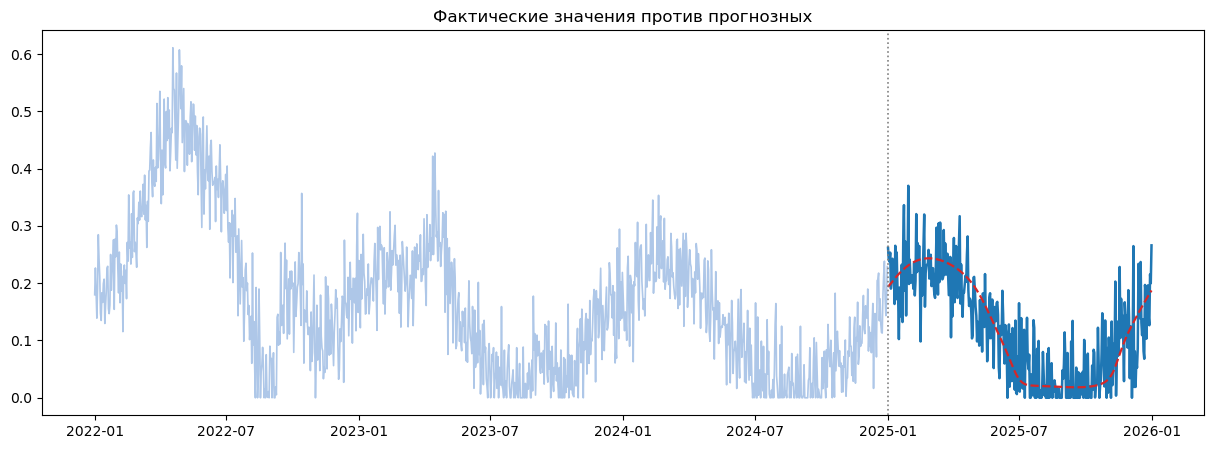

In [69]:
plot_forecast(train.loc['2022':], test, pd.DataFrame(test_fcst, index = test.index))

# Классификация

In [70]:
df_po = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_orders_clean.csv")

df_suppliers = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_suppliers.csv")
    .loc[:, ["supplier_id", "country_id", "years_of_relationship", "maturity_score", "min_order_usd"]]
)

df_transport_modes = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_transport_modes.csv")
    .loc[:, ["transport_mode_id", "avg_transit_days", "delay_probability"]]
)

df = (
    df_po
    .merge(df_suppliers, how = "left", on = "supplier_id")
    .merge(df_transport_modes, how = "left", on = "transport_mode_id")
)

In [71]:
cat_cols = [
    "transport_mode_id",
    "payment_method"
]

num_cols = [
    "years_of_relationship",
    "supplier_reliability",
    "maturity_score",
    "min_order_usd"    
]
target_col = ["is_fraud"]

In [72]:
data = df.copy()
data = data.sort_values(by = "po_id")
data = data.set_index("po_id")

In [73]:
X = data[num_cols + cat_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

# =====================================================
# PyTorch tensors
# =====================================================

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

batch_size = 256

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [75]:
input_dim = X_train_tensor.shape[1]

class BinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)   # logits
        )

    def forward(self, x):
        return self.network(x)

model = BinaryClassifier(input_dim)

In [76]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


n_epochs = 50

for epoch in range(n_epochs):

    model.train()

    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item() * len(X_batch)

    epoch_loss /= len(train_dataset)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{n_epochs}, "
            f"Loss: {epoch_loss:.6f}"
        )

model.eval()

with torch.no_grad():

    logits = model(X_test_tensor)

    probs = torch.sigmoid(logits)

    preds = (probs >= 0.5).float()

# Convert to numpy

y_prob = probs.cpu().numpy().ravel()
y_pred = preds.cpu().numpy().ravel().astype(int)

Epoch 10/50, Loss: 0.154113
Epoch 20/50, Loss: 0.033390
Epoch 30/50, Loss: 0.005234
Epoch 40/50, Loss: 0.001446
Epoch 50/50, Loss: 0.000640


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


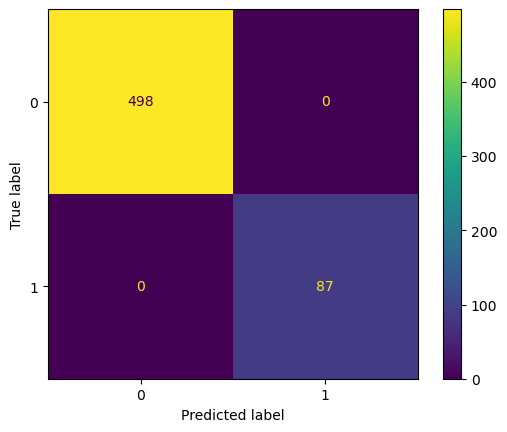

In [80]:
def evaluate_model(y_pred, y_test):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))

evaluate_model(y_pred, y_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Эмбеддинги и кластеризация

In [82]:
df_po_descriptions = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_order_descriptions.csv")

In [83]:
df_po_descriptions.head()

,po_id,description_text
0,1,Internal audit identified a certification mism...
1,2,The quality control team issued a non-conforma...
2,3,This is a scheduled replenishment order for Wo...
3,4,A rush order for Hydraulic Pumps has been plac...
4,5,Standard monthly reorder of CNC Machine Parts ...


In [94]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

embeddings = model.encode(
    df_po_descriptions["description_text"].astype(str).values.tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print(embeddings.shape)

Batches:   0%|          | 0/88 [00:00<?, ?it/s]

(2796, 384)


In [95]:
pip install umap-learn


   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]

Note: you may need to restart the kernel to use updated packages.


In [96]:
from sklearn.cluster import KMeans

n_clusters = 8

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42
)

cluster_labels = kmeans.fit_predict(
    embeddings
)

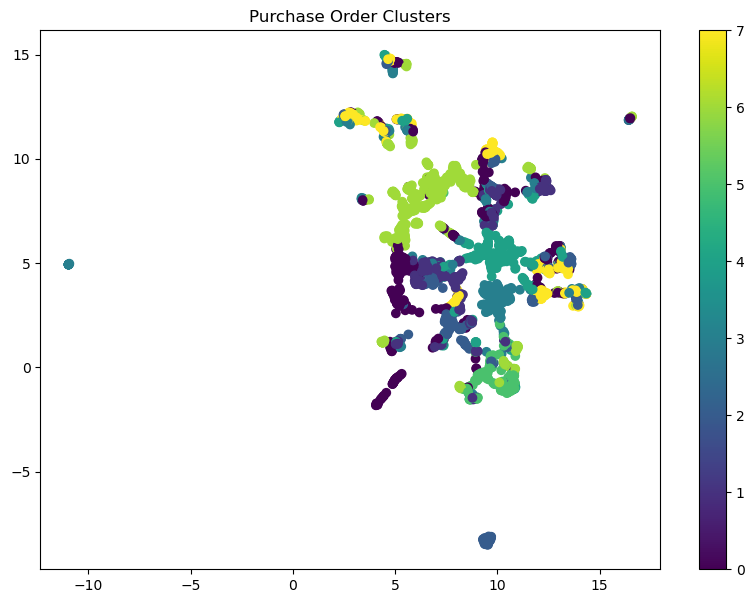

In [97]:
import umap

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(
    embeddings
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=cluster_labels
)

plt.colorbar(scatter)
plt.title("Purchase Order Clusters")
plt.show()

In [101]:
import pandas as pd

df_po_descriptions["cluster"] = cluster_labels

for cluster in sorted(df_po_descriptions["cluster"].unique()):
    print("\n")
    print("=" * 50)
    print(f"Cluster {cluster}")

    sample = (
        df_po_descriptions[df_po_descriptions["cluster"] == cluster]
        .loc[:, "description_text"]
        .tolist()
    )

    for s in sample[:10]:
        print("-", s)



Cluster 0
- Internal audit identified a certification mismatch for Industrial Bearings supplied by Minsk MachineWorks BY; this corrective order ensures compliant stock availability. The unit price on this replacement order reflects a 10% credit agreed with Minsk MachineWorks BY as partial compensation for disruption. All received units from this replacement order will undergo 100% incoming inspection upon arrival.
- The quality control team issued a non-conformance report for Cotton Yarn 32s from Polish Textile Partners; this order restores inventory to operational levels. The supplier has been placed on a provisional watch list pending the outcome of the root cause analysis. The unit price on this replacement order reflects a 10% credit agreed with Polish Textile Partners as partial compensation for disruption. Future shipments from Polish Textile Partners will require a pre-shipment inspection certificate until further notice.
- The quality control team issued a non-conformance rep

# Тональность

In [103]:
from transformers import pipeline

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

sentiments = sentiment_pipe(
    df_po_descriptions["description_text"].astype(str).values.tolist(),
    truncation=True
)

Device set to use cpu


In [111]:
df_po_descriptions["sentiment"] = np.array([x["label"] for x in sentiments]).reshape(-1, 1)
df_po_descriptions["sentiment_score"] = np.array([x["score"] for x in sentiments]).reshape(-1, 1)

In [116]:
df_po_descriptions.head()

,po_id,description_text,cluster,sentiment,sentiment_score
0,1,Internal audit identified a certification mism...,0,NEGATIVE,0.986028
1,2,The quality control team issued a non-conforma...,0,NEGATIVE,0.992984
2,3,This is a scheduled replenishment order for Wo...,1,NEGATIVE,0.985642
3,4,A rush order for Hydraulic Pumps has been plac...,3,NEGATIVE,0.993433
4,5,Standard monthly reorder of CNC Machine Parts ...,1,NEGATIVE,0.991712


[]

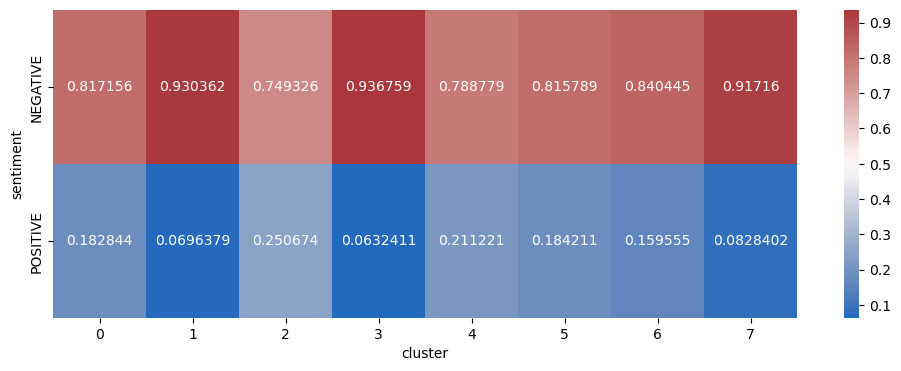

In [123]:
fig, ax = plt.subplots(1,1, figsize = (12,4))
crosstab = pd.crosstab(df_po_descriptions["cluster"], df_po_descriptions["sentiment"], normalize = 'index').T
sns.heatmap(crosstab, cmap = "vlag", annot = True, fmt = "g", ax = ax)
plt.plot()